This notebook defines flooding severity for each gauge according to the Log-Pearson Type III Dsitribution

In [1]:
import polars as pl
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import wandb
import numpy as np
import os
import gc
import re

In [2]:
# Set global row display limit for Polars DataFrames
pl.Config.set_tbl_rows(20)

polars.config.Config

In [3]:
# Connect to Weights and Biases API
api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\mroth\.netrc.


In [4]:
# Load the raw daily streamflow max dataset from wandb
artifact = api.artifact("flood-forecasting/flood-dataset-daily-summary:latest")
artifact_dir = artifact.download()

# Read the parquet file
sfd_df = pl.read_parquet(os.path.join(artifact_dir, "flood_model_daily_summary.parquet"))

# Filter out null values (-999,999) in streamflow_cfs_max
sfd_df = sfd_df.filter(pl.col("streamflow_cfs_max") != -999999)

# Limit the dataset to 2024 or earlier.
sfd_df = sfd_df.filter(pl.col("observed_date").dt.year() <= 2024)

wandb:   1 of 1 files downloaded.  


In [5]:
print(f"Full dataset: {sfd_df.shape[0]:,} rows x {sfd_df.shape[1]} columns")
print(f"Total sites: {sfd_df['site_id'].n_unique()}")
print(sfd_df.head())
print(f"Date range: {sfd_df['observed_date'].min()} to {sfd_df['observed_date'].max()}")

size_mb = sfd_df.estimated_size("mb")
print(f"{size_mb:.2f} MB")

Full dataset: 3,828,719 rows x 4 columns
Total sites: 939
shape: (5, 4)
┌──────────┬───────────────┬────────────────────┬────────────────────┐
│ site_id  ┆ observed_date ┆ streamflow_cfs_max ┆ gage_height_ft_max │
│ ---      ┆ ---           ┆ ---                ┆ ---                │
│ str      ┆ date          ┆ f64                ┆ f64                │
╞══════════╪═══════════════╪════════════════════╪════════════════════╡
│ 06017000 ┆ 2015-07-09    ┆ 203.0              ┆ 3.85               │
│ 06017000 ┆ 2015-07-22    ┆ 163.0              ┆ 3.75               │
│ 06017000 ┆ 2015-07-28    ┆ 172.0              ┆ 3.82               │
│ 06017000 ┆ 2015-08-02    ┆ 121.0              ┆ 3.6                │
│ 06017000 ┆ 2015-08-04    ┆ 130.0              ┆ 3.66               │
└──────────┴───────────────┴────────────────────┴────────────────────┘
Date range: 2007-10-28 to 2024-07-11
102.93 MB


The catchment attributes table does not contain data on all sites. Therefore we must use it as a filter.

In [6]:
import duckdb

con = duckdb.connect("../../data/database/database.duckdb", read_only=True)

ca_df = con.execute("SELECT * FROM main_marts.dim_catchment_attributes_full").pl()
con.close()

print(ca_df.shape)

(9008, 561)


In [7]:
# Function for creating annual peaks DataFrame for Log-Pearson Type III Distribution Fitting

def calc_annual_peaks(df, station_col,streamflow_col, date_col,):
    """
    Takes a polars Dataframe and calculates the annual discharge peaks for each station. 
    
    Inputs:
        df: Polars DataFrame containing streamflow data
        station_col: Name of the column containing station identifiers (e.g., 'site_id')
        streamflow_col: Name of the column containing streamflow values (e.g., 'streamflow_cfs_mean')
        date_col: Name of the column containing date values (e.g., 'date')
    Returns:
        New DataFrame with columns for station_id, year, peak_discharge, and peak_date.
    """
    return (
        df
        .filter(pl.col(streamflow_col).is_not_null()) 
        .filter(pl.col(streamflow_col) > 0) 
        .with_columns([
            # Calculate  year
            pl.when(pl.col(date_col).dt.month() >= 10)
            .then(pl.col(date_col).dt.year() + 1)
            .otherwise(pl.col(date_col).dt.year())
            .alias("year")
        ])
        .group_by([station_col, "year"])
        .agg([
            pl.col(streamflow_col).max().alias("peak_discharge_cfs"),
            pl.col(date_col).sort_by(streamflow_col).last().dt.date().alias("peak_date")
        ])
        .sort([station_col, "year"])
    )

In [8]:
annual_peaks_sfd = calc_annual_peaks(sfd_df, "site_id", "streamflow_cfs_max", "observed_date")

# Remove sites that are not found in the catchment attributes dataset
annual_peaks_sfd = annual_peaks_sfd.join(
    ca_df.select("site_id"),
    on="site_id",
    how="semi"
)



print(f"Annual peaks extracted: {annual_peaks_sfd.shape[0]:,} site-years")
print(annual_peaks_sfd.head())

Annual peaks extracted: 9,526 site-years
shape: (5, 4)
┌──────────┬──────┬────────────────────┬────────────┐
│ site_id  ┆ year ┆ peak_discharge_cfs ┆ peak_date  │
│ ---      ┆ ---  ┆ ---                ┆ ---        │
│ str      ┆ i32  ┆ f64                ┆ date       │
╞══════════╪══════╪════════════════════╪════════════╡
│ 06006000 ┆ 2008 ┆ 156.0              ┆ 2008-06-23 │
│ 06006000 ┆ 2009 ┆ 141.0              ┆ 2009-06-21 │
│ 06006000 ┆ 2010 ┆ 146.0              ┆ 2010-06-05 │
│ 06006000 ┆ 2011 ┆ 245.0              ┆ 2011-06-30 │
│ 06006000 ┆ 2012 ┆ 154.0              ┆ 2012-06-06 │
└──────────┴──────┴────────────────────┴────────────┘


In [9]:
# Create the site mapping from ca_df
site_df = ca_df.select(["site_id", "LAT_GAGE", "LNG_GAGE", "state_gage", "ELEV_SITE_M"]).rename({"LAT_GAGE": "latitude", "LNG_GAGE": "longitude", "state_gage": "state", "ELEV_SITE_M": "elevation_m"})

print(site_df.head())

shape: (5, 5)
┌──────────┬───────────┬────────────┬───────┬─────────────┐
│ site_id  ┆ latitude  ┆ longitude  ┆ state ┆ elevation_m │
│ ---      ┆ ---       ┆ ---        ┆ ---   ┆ ---         │
│ str      ┆ f64       ┆ f64        ┆ str   ┆ i32         │
╞══════════╪═══════════╪════════════╪═══════╪═════════════╡
│ 01015800 ┆ 46.523003 ┆ -68.371764 ┆ ME    ┆ 166         │
│ 01016500 ┆ 46.628311 ┆ -68.434792 ┆ ME    ┆ 165         │
│ 01017000 ┆ 46.777294 ┆ -68.157194 ┆ ME    ┆ 131         │
│ 01017060 ┆ 46.783611 ┆ -67.989167 ┆ ME    ┆ 155         │
│ 01017290 ┆ 46.88861  ┆ -67.945    ┆ ME    ┆ 137         │
└──────────┴───────────┴────────────┴───────┴─────────────┘


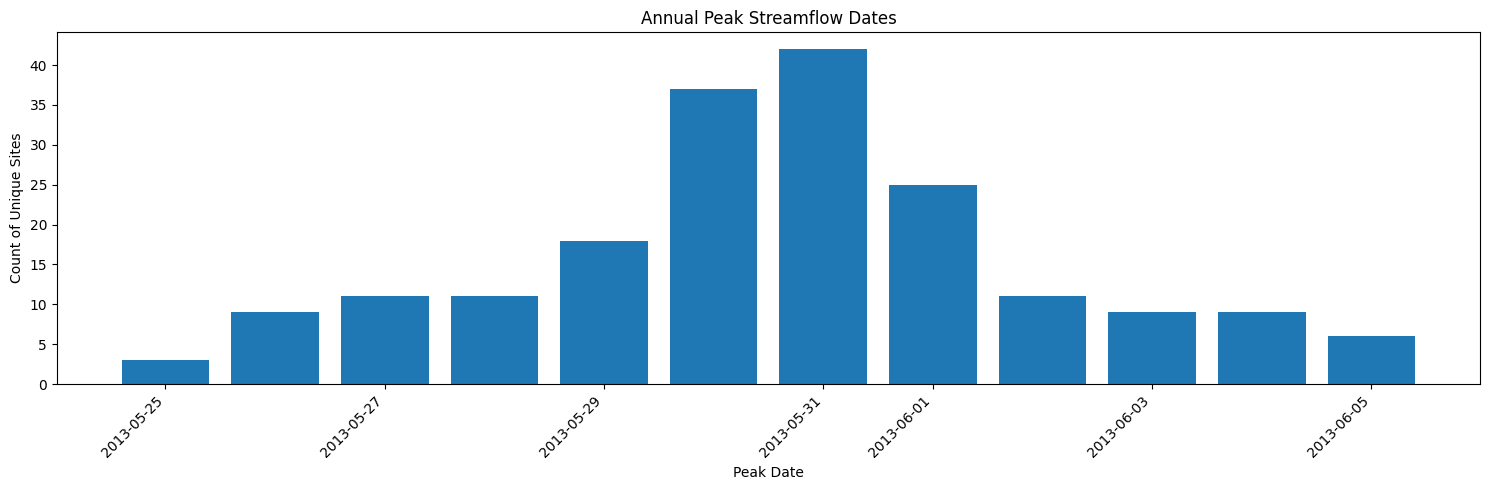

In [10]:
import matplotlib.pyplot as plt
from datetime import date

# Count unique site_ids per peak_date
peak_date_counts = (
    annual_peaks_sfd
    .group_by("peak_date")
    .agg(pl.col("site_id").n_unique().alias("site_count"))
    .sort("peak_date")
)

# Convert to pandas for matplotlib
# Apply date limits on the dataset
pdf = peak_date_counts.filter(
    (pl.col("peak_date") >= date(2013, 5, 25)) & 
    (pl.col("peak_date") <= date(2013, 6, 5))
).to_pandas()

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(pdf["peak_date"], pdf["site_count"])

ax.set_xlabel("Peak Date")
ax.set_ylabel("Count of Unique Sites")
ax.set_title("Annual Peak Streamflow Dates")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Calculate Log-Pearson Type III Distribution Stats for Flood Measurements

In [11]:
# Create dictionary of regional skew values and MSE for Log-Pearson Type III distribution fitting

REGIONAL_SKEW_BY_STATE = {
    # Upper Midwest
    "IA": {"skew": -0.20, "mse": 0.25}, # Iowa
    "MO": {"skew": -0.30, "mse": 0.14}, # Missouri (SIR 2014-5165)
    
    # Northern Plains
    "ND": {"skew": -0.30, "mse": 0.30}, # North Dakota
    "SD": {"skew": -0.30, "mse": 0.30}, # South Dakota
    "NE": {"skew": -0.30, "mse": 0.30}, # Nebraska
    "KS": {"skew": -0.20, "mse": 0.30}, # Kansas
    
    # Rocky Mountain
    "MT": {"skew": -0.20, "mse": 0.30}, # Montana
    "WY": {"skew": -0.10, "mse": 0.30}, # Wyoming
    "CO": {"skew": -0.10, "mse": 0.30}, # Colorado
}

DEFAULT_REGIONAL_SKEW = {"skew": -0.20, "mse": 0.302}

In [12]:
def get_regional_skew(state_abbrev: str) -> tuple[float, float]:
    """
    Get regional skew coefficient and MSE for a given state.
    
    Inputs:
        state_abbrev : str
            Two-letter state abbreviation (e.g., 'CA', 'TX', 'NY')
    
    Output:
        tuple[float, float] : (regional_skew, regional_mse)
    """
    state = state_abbrev.upper()
    skew_dict = REGIONAL_SKEW_BY_STATE.get(state, DEFAULT_REGIONAL_SKEW)
    return skew_dict["skew"], skew_dict["mse"]

In [13]:
def calc_station_skew_mse(station_skew, n_years):
    """
    Approximation for station skew MSE that accounts for skewness.
    
    Inputs:
        station_skew : float
            G (gamma hat) - the sample skewness of log-transformed peaks
        n_years : int
            Number of years of record
    Outputs:
        Mean Squared Error (MSE) of the station skew estimate, accounting for skewness and sample size.
    """
    G = station_skew  
    n = n_years
    
    mse = ((6/n) + (9/n**2) + (15*G**2/n) + (10*G**2/n**2)) / (1 + 0.75*G**2)**2
    
    return mse

In [14]:
def calc_weighted_skew(station_skew, station_mse, regional_skew, regional_mse):
    """
    Calculate weighted skew using inverse MSE weighting per Bulletin 17C.
    
    Inputs:
        station_skew
            Station skew coefficient (G)
        station_mse
            MSE of station skew
        regional_skew
            Regional skew coefficient
        regional_mse
            MSE of regional skew
    
    Outputs:
        Gfloat : Weighted skew coefficient
    """
    # Inverse MSE weighting
    weight_station = regional_mse / (station_mse + regional_mse)
    weight_regional = station_mse / (station_mse + regional_mse)
    
    weighted_skew = weight_station * station_skew + weight_regional * regional_skew
    
    return weighted_skew

In [15]:
def calc_mgb_critical_value(n: int, alpha: float = 0.10) -> float:
    """
    Calculate the Grubbs-Beck critical value K_n for sample size n and significance level alpha.
    
    Parameters:
    -----------
    n : int
        Sample size (number of years)
    alpha : float
        Significance level (default 0.10 for MGB test)
    
    Returns:
    --------
    float
        Critical value K_n
    """
    
    if n < 10:
        return np.nan
    
    # Grubbs-Beck critical value using t-distribution
    # K_n = t_(alpha/n, n-2) * sqrt((n-1) / (n - 2 + t^2))the
    t_crit = stats.t.ppf(1 - alpha / n, df=n - 2)
    K_n = t_crit * np.sqrt((n - 1) / (n - 2 + t_crit**2))
    
    return K_n

In [16]:
def calc_mgb_threshold(peaks: np.ndarray, alpha: float = 0.10, max_iterations: int = 50) -> dict:
    """
    Calculate the Multiple Grubbs-Beck PILF threshold iteratively.
    """
    valid_peaks = peaks[peaks > 0]
    if len(valid_peaks) < 10:
        return {
            "pilf_threshold_cfs": np.nan,
            "pilf_threshold_log": np.nan,
            "n_pilfs": 0,
            "n_retained": len(valid_peaks)
        }
    
    log_peaks = np.log10(valid_peaks)
    working_logs = np.sort(log_peaks)
    n_original = len(working_logs)
    n_pilfs = 0
    
    for iteration in range(max_iterations):
        n = len(working_logs)
        if n < 10:
            break
        
        mean_log = np.mean(working_logs)
        std_log = np.std(working_logs, ddof=1)
        
        if std_log == 0:
            break
        
        K_n = calc_mgb_critical_value(n, alpha)
        threshold_log = mean_log - K_n * std_log
        
        if working_logs[0] < threshold_log:
            working_logs = working_logs[working_logs >= threshold_log]
            n_removed = n - len(working_logs)
            n_pilfs += n_removed
        else:
            break
    
    if len(working_logs) >= 10:
        mean_log = np.mean(working_logs)
        std_log = np.std(working_logs, ddof=1)
        K_n = calc_mgb_critical_value(len(working_logs), alpha)
        final_threshold_log = mean_log - K_n * std_log
        final_threshold_cfs = 10 ** final_threshold_log
    else:
        final_threshold_log = np.nan
        final_threshold_cfs = np.nan
    
    return {
        "pilf_threshold_cfs": final_threshold_cfs,
        "pilf_threshold_log": final_threshold_log,
        "n_pilfs": n_pilfs,
        "n_retained": n_original - n_pilfs
    }

In [17]:
from scipy import stats
from scipy.stats import pearson3

def calc_lp3_quantile(mean_log, std_log, skew, return_period):
    """
    Calculate flood discharge for a given return period using LP3 distribution.
    
    Inputs:
    mean_log : float
        Mean of log-transformed peak flows
    std_log : float
        Standard deviation of log-transformed peak flows
    skew : float
        Skew coefficient (weighted or station)
    return_period : int
        Return period in years (e.g., 10, 50, 100)
    
    Returns:
    --------
    float : Estimated discharge in cfs
    """
    p = 1 - 1/return_period  # Non-exceedance probability
    
    # Use scipy's pearson3.ppf for the frequency factor
    log_Q = pearson3.ppf(p, skew, loc=mean_log, scale=std_log)
    
    # Back-transform to cfs
    Q = 10 ** log_Q
    
    return Q

In [22]:
def calc_lp3_analysis(
    annual_peaks_df: pl.DataFrame,
    site_df: pl.DataFrame,
    station_col: str = "site_id",
    discharge_col: str = "peak_discharge_cfs",
    year_col: str = "year",
    state_col: str = "state_gage",
    min_years: int = 10,
    return_periods: list = [2, 5, 10, 25, 50, 100],
    calc_mgb: bool = True,
    mgb_alpha: float = 0.10
) -> pl.DataFrame:
    """
    Calculate LP3 flood frequency analysis for multiple sites.
    
    Inputs:
        annual_peaks_df : pl.DataFrame
            DataFrame with columns [site_id, year, peak_discharge_cfs]
        site_state_df : pl.DataFrame
            DataFrame with columns [site_id, state_gage, LAT_GAGE, LNG_GAGE]
        station_col : str
            Name of station ID column
        discharge_col : str
            Name of discharge column
        year_col : str
            Name of year column
        state_col : str
            Name of state column in site_state_df
        min_years : int
            Minimum years of record required
        return_periods : list
            Return periods to calculate quantiles for
        calc_mgb : bool
            Whether to calculate MGB/PILF threshold (default True)
        mgb_alpha : float
            Significance level for MGB test (default 0.10)
    
    Outputs:
        pl.DataFrame
            Results with LP3 parameters, quantiles, and optionally MGB threshold
    """
    
    results = []
    sites = annual_peaks_df[station_col].unique().to_list()
    
    for site_id in sites:
        # Filter data for this site
        site_data = (
            annual_peaks_df
            .filter(pl.col(station_col) == site_id)
            .filter(pl.col(discharge_col).is_not_null())
            .filter(pl.col(discharge_col) > 0)
        )
        
        n_years = site_data.shape[0]
        
        if n_years < min_years:
            continue
        
        # Get peaks as numpy array
        peaks = site_data[discharge_col].to_numpy()
        log_peaks = np.log10(peaks)
        
        # Get state and coordinates
        site_info = site_df.filter(pl.col(station_col) == site_id)
        if site_info.shape[0] == 0:
            continue
        
        state = site_info[state_col].to_list()[0]
        
        # Calculate statistics
        mean_log = np.mean(log_peaks)
        std_log = np.std(log_peaks, ddof=1)
        
        # Station skew
        n = len(log_peaks)
        station_skew = stats.skew(log_peaks, bias=False)
        
        # Station skew MSE (Griffis & Stedinger 2009)
        G = station_skew
        station_mse = ((6/n) + (9/n**2) + (15*G**2/n) + (10*G**2/n**2)) / (1 + 0.75*G**2)**2
        
        # Regional skew
        regional_skew, regional_mse = get_regional_skew(state)
        
        # Weighted skew
        weight_station = regional_mse / (station_mse + regional_mse)
        weight_regional = station_mse / (station_mse + regional_mse)
        weighted_skew = weight_station * station_skew + weight_regional * regional_skew
        
        # Build row
        row = {
            station_col: site_id,
            "state": state,
            "n_years": n_years,
            "mean_log": mean_log,
            "std_log": std_log,
            "station_skew": station_skew,
            "station_mse": station_mse,
            "regional_skew": regional_skew,
            "regional_mse": regional_mse,
            "weighted_skew": weighted_skew
        }
        
        # MGB/PILF calculation
        if calc_mgb:
            mgb_results = calc_mgb_threshold(peaks, alpha=mgb_alpha)
            row["pilf_threshold_cfs"] = mgb_results["pilf_threshold_cfs"]
            row["pilf_threshold_log"] = mgb_results["pilf_threshold_log"]
            row["n_pilfs"] = mgb_results["n_pilfs"]
            row["n_retained"] = mgb_results["n_retained"]
        
        # Calculate quantiles for each return period
        for T in return_periods:
            aep = 1 / T
            non_exceedance_prob = 1 - aep
            log_Q = pearson3.ppf(non_exceedance_prob, weighted_skew, loc=mean_log, scale=std_log)
            Q = 10 ** log_Q
            row[f"Q{T}_cfs"] = Q
        
        results.append(row)
    
    return pl.DataFrame(results)

In [23]:
# Run the LP3 analysis
lp3_results = calc_lp3_analysis(
    annual_peaks_df=annual_peaks_sfd,
    site_df=site_df,
    station_col="site_id",
    discharge_col="peak_discharge_cfs",
    state_col="state",
    return_periods=[2, 5, 10, 25, 50, 100],
    min_years=10
)



In [24]:
# Add the latitude and longitude from site_df to the results for mapping and spatial analysis
lp3_results = lp3_results.join(
    site_df.select(["site_id", "latitude", "longitude", "elevation_m"]),
    on="site_id",
    how="left"
)

In [25]:
print(lp3_results.head())

shape: (5, 23)
┌──────────┬───────┬─────────┬──────────┬───┬──────────────┬───────────┬─────────────┬─────────────┐
│ site_id  ┆ state ┆ n_years ┆ mean_log ┆ … ┆ Q100_cfs     ┆ latitude  ┆ longitude   ┆ elevation_m │
│ ---      ┆ ---   ┆ ---     ┆ ---      ┆   ┆ ---          ┆ ---       ┆ ---         ┆ ---         │
│ str      ┆ str   ┆ i64     ┆ f64      ┆   ┆ f64          ┆ f64       ┆ f64         ┆ i32         │
╞══════════╪═══════╪═════════╪══════════╪═══╪══════════════╪═══════════╪═════════════╪═════════════╡
│ 06076690 ┆ MT    ┆ 16      ┆ 2.757977 ┆ … ┆ 3519.474135  ┆ 46.795782 ┆ -111.17884  ┆ 1343        │
│ 06622700 ┆ WY    ┆ 17      ┆ 2.852498 ┆ … ┆ 1743.654813  ┆ 41.370245 ┆ -106.520581 ┆ 2463        │
│ 06345500 ┆ ND    ┆ 17      ┆ 3.194659 ┆ … ┆ 48374.148339 ┆ 46.745556 ┆ -102.308333 ┆ 664         │
│ 06635000 ┆ WY    ┆ 17      ┆ 3.068288 ┆ … ┆ 5313.07942   ┆ 42.009684 ┆ -106.513083 ┆ 1958        │
│ 06422500 ┆ SD    ┆ 17      ┆ 2.199015 ┆ … ┆ 1950.509991  ┆ 44.143876 ┆ -10

In [ ]:
# Save the results to a csv file to the hard drive.
# lp3_results.write_csv(r"C:\Users\mroth\OneDrive\Documents\Rice\COMP 549 DSCI 535 901 Capstone\Project\lp3_results.csv")

Count Flooding Events for each Time Period's Streamflow Threshold

In [27]:
def get_flooding_events(
    daily_df: pl.DataFrame,
    lp3_results: pl.DataFrame,
    station_col: str = "site_id",
    discharge_col: str = "streamflow_cfs",
    datetime_col: str = "observed_date"
) -> pl.DataFrame:
    """
    Identify all flooding events for each site using contiguous exceedance blocks.
    A new event is only counted when flow drops below Q2/2 between peaks.

    Parameters:
    -----------
    daily_df : pl.DataFrame
        DataFrame with columns [site_id, datetime, streamflow_cfs] at daily resolution
    lp3_results : pl.DataFrame
        DataFrame with LP3 quantiles (Q2_cfs, Q5_cfs, etc.)
    station_col : str
        Name of site ID column
    discharge_col : str
        Name of discharge column
    datetime_col : str
        Name of datetime column

    Returns:
    --------
    pl.DataFrame : Table of all flooding events with site_id, datetime, streamflow_cfs, classification
    """

    quantile_order = ["Q100_cfs", "Q50_cfs", "Q25_cfs", "Q10_cfs", "Q5_cfs", "Q2_cfs"]
    event_records = []

    for row in lp3_results.iter_rows(named=True):
        site_id = row[station_col]
        q2 = row["Q2_cfs"]

        if q2 is None:
            continue

        q2_half = q2 / 2

        site_df = (
            daily_df
            .filter(pl.col(station_col) == site_id)
            .filter(pl.col(discharge_col).is_not_null())
            .select([datetime_col, discharge_col])
            .sort(datetime_col)
        )

        if site_df.is_empty():
            continue

        datetimes = site_df[datetime_col].to_list()
        flows = site_df[discharge_col].to_list()

        # Group into contiguous exceedance blocks using Q2/2 as separation threshold
        exceedance_blocks = []
        current_block = []

        for i, flow in enumerate(flows):
            if flow >= q2:
                current_block.append(i)
            elif current_block and flow >= q2_half:
                current_block.append(i)
            else:
                if current_block:
                    exceedance_blocks.append(current_block)
                    current_block = []
        if current_block:
            exceedance_blocks.append(current_block)

        # Find peak of each block and classify
        for block in exceedance_blocks:
            peak_idx = max(block, key=lambda j: flows[j])
            peak_flow = flows[peak_idx]
            peak_dt = datetimes[peak_idx]

            classification = None
            for q in quantile_order:
                threshold = row.get(q)
                if threshold is not None and peak_flow >= threshold:
                    classification = q.replace("_cfs", "")
                    break

            event_records.append({
                station_col: site_id,
                datetime_col: peak_dt,
                discharge_col: peak_flow,
                "classification": classification
            })

    flooding_events = pl.DataFrame(event_records).sort([station_col, datetime_col])

    print(f"Total flooding events: {len(flooding_events)}")
    print(flooding_events.head(10))

    return flooding_events




In [31]:
flooding_events = get_flooding_events(
    daily_df=sfd_df,
    lp3_results=lp3_results,
    station_col="site_id",
    discharge_col="streamflow_cfs_max",
)

Total flooding events: 7232
shape: (10, 4)
┌──────────┬───────────────┬────────────────────┬────────────────┐
│ site_id  ┆ observed_date ┆ streamflow_cfs_max ┆ classification │
│ ---      ┆ ---           ┆ ---                ┆ ---            │
│ str      ┆ date          ┆ f64                ┆ str            │
╞══════════╪═══════════════╪════════════════════╪════════════════╡
│ 06006000 ┆ 2008-06-23    ┆ 156.0              ┆ Q2             │
│ 06006000 ┆ 2011-06-30    ┆ 245.0              ┆ Q10            │
│ 06006000 ┆ 2012-06-06    ┆ 154.0              ┆ Q2             │
│ 06006000 ┆ 2014-05-29    ┆ 155.0              ┆ Q2             │
│ 06006000 ┆ 2017-06-13    ┆ 181.0              ┆ Q2             │
│ 06006000 ┆ 2018-06-01    ┆ 175.0              ┆ Q2             │
│ 06006000 ┆ 2019-06-08    ┆ 184.0              ┆ Q2             │
│ 06006000 ┆ 2022-06-13    ┆ 231.0              ┆ Q10            │
│ 06006000 ┆ 2023-06-15    ┆ 184.0              ┆ Q2             │
│ 06012500 ┆ 2009-0

In [ ]:
# Save the results to a csv file to the hard drive.
# flooding_events.write_csv(r"C:\Users\mroth\OneDrive\Documents\Rice\COMP 549 DSCI 535 901 Capstone\Project\flooding_events.csv")

In [33]:
def count_floods_by_quantile(
    flooding_events: pl.DataFrame,
    lp3_results: pl.DataFrame,
    station_col: str = "site_id",
    discharge_col: str = "streamflow_cfs_max"
) -> pl.DataFrame:
    """
    Count flooding events per site that exceed each quantile threshold.
    A single large event counts toward all lower quantiles it exceeds.

    Parameters:
    -----------
    flooding_events : pl.DataFrame
        DataFrame with columns [site_id, observed_date, streamflow_cfs, classification]
    lp3_results : pl.DataFrame
        DataFrame with LP3 quantiles (Q2_cfs, Q5_cfs, etc.)
    station_col : str
        Name of site ID column
    discharge_col : str
        Name of discharge column

    Returns:
    --------
    pl.DataFrame : lp3_results with floods_Q* count columns added
    """

    q_columns = [col for col in lp3_results.columns if col.startswith("Q") and col.endswith("_cfs")]

    flood_counts = []

    for row in lp3_results.iter_rows(named=True):
        site_id = row[station_col]

        # Get all event peaks for this site
        site_peaks = (
            flooding_events
            .filter(pl.col(station_col) == site_id)
            .filter(pl.col(discharge_col).is_not_null())
            .select(discharge_col)
            .to_numpy()
            .flatten()
        )

        counts = {station_col: site_id}

        # Count events exceeding each quantile — a Q100 event counts toward Q50, Q25, etc.
        for q_col in q_columns:
            threshold = row[q_col]
            if threshold is not None and len(site_peaks) > 0:
                count = int(np.sum(site_peaks >= threshold))
            else:
                count = 0

            return_period = q_col.replace("_cfs", "").replace("Q", "")
            counts[f"floods_Q{return_period}"] = count

        flood_counts.append(counts)

    flood_counts_df = pl.DataFrame(flood_counts)

    result = lp3_results.join(
        flood_counts_df,
        on=station_col,
        how="left"
    )

    return result

In [34]:
# Calculate the Log-Pearson Type III quantiles and flood counts for each site
lp3_results = count_floods_by_quantile(
    flooding_events=flooding_events,
    lp3_results=lp3_results,
    station_col="site_id",
    discharge_col="streamflow_cfs_max"
)

In [35]:
# Save the results to a csv file to the hard drive.
lp3_results.write_csv(r"C:\Users\mroth\OneDrive\Documents\Rice\COMP 549 DSCI 535 901 Capstone\Project\lp3_results.csv")

In [37]:
def calc_weighted_flood_severity_score(
    lp3_results: pl.DataFrame,
    n_years_col: str = "n_years"
) -> pl.DataFrame:
    """
    Adds a 'flood_severity_score' column to lp3_results.

    For each quantile tier, counts are classified as:
        count_QT = floods_QT - floods_Q(next larger T)
    The largest quantile tier count = floods_Q(max) as-is.

    Weight per tier = sqrt(T) * count_QT
    Score = sum(weights) / n_years
    """
    # Drop any spurious join artifact columns (e.g. "floods_Q100_right")
    right_cols = [c for c in lp3_results.columns if c.endswith("_right")]
    lp3_results = lp3_results.drop(right_cols)
    
    # Extract quantile return periods from column names (e.g. "floods_Q100" -> 100)
    flood_cols = sorted(
        [c for c in lp3_results.columns if c.startswith("floods_Q")],
        key=lambda c: int(c.split("Q")[1])
    )
    quantiles = [int(c.split("Q")[1]) for c in flood_cols]  # e.g. [2, 5, 10, 25, 50, 100]

    # Sort descending so we can subtract the next larger tier
    flood_cols_desc = list(reversed(flood_cols))       # [floods_Q100, floods_Q50, ...]
    quantiles_desc = list(reversed(quantiles))         # [100, 50, 25, ...]

    # Build expression for each tier's weighted component
    weight_exprs = []
    for i, (T, col) in enumerate(zip(quantiles_desc, flood_cols_desc)):
        if i == 0:
            # Largest quantile: count is just floods_Q(max)
            count_expr = pl.col(col)
        else:
            # Subtract next larger tier to isolate events in this band
            prev_col = flood_cols_desc[i - 1]
            count_expr = pl.col(col) - pl.col(prev_col)

        weight_expr = (count_expr * (T ** 0.5)).alias(f"_w_Q{T}")
        weight_exprs.append(weight_expr)

    # Compute weighted components and sum them
    result = lp3_results.with_columns(weight_exprs)

    weight_col_names = [f"_w_Q{T}" for T in quantiles_desc]
    score_expr = sum(pl.col(c) for c in weight_col_names) / pl.col(n_years_col)

    result = (
        result
        .with_columns(score_expr.alias("flood_severity_score"))
        .drop(weight_col_names)  # clean up intermediate columns
        .sort("flood_severity_score", descending=True)
    )

    return result

In [38]:
lp3_results = calc_weighted_flood_severity_score(lp3_results)

In [39]:
with pl.Config(tbl_cols=-1):
    print(lp3_results.head(10))

shape: (10, 30)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ sit ┆ sta ┆ n_y ┆ mea ┆ std ┆ sta ┆ sta ┆ reg ┆ reg ┆ wei ┆ pil ┆ pil ┆ n_p ┆ n_r ┆ Q2_ ┆ Q5_ ┆ Q10 ┆ Q25 ┆ Q50 ┆ Q10 ┆ lat ┆ lon ┆ ele ┆ flo ┆ flo ┆ flo ┆ flo ┆ flo ┆ flo ┆ flo │
│ e_i ┆ te  ┆ ear ┆ n_l ┆ _lo ┆ tio ┆ tio ┆ ion ┆ ion ┆ ght ┆ f_t ┆ f_t ┆ ilf ┆ eta ┆ cfs ┆ cfs ┆ _cf ┆ _cf ┆ _cf ┆ 0_c ┆ itu ┆ git ┆ vat ┆ ods ┆ ods ┆ ods ┆ ods ┆ ods ┆ ods ┆ od_ │
│ d   ┆ --- ┆ s   ┆ og  ┆ g   ┆ n_s ┆ n_m ┆ al_ ┆ al_ ┆ ed_ ┆ hre ┆ hre ┆ s   ┆ ine ┆ --- ┆ --- ┆ s   ┆ s   ┆ s   ┆ fs  ┆ de  ┆ ude ┆ ion ┆ _Q2 ┆ _Q5 ┆ _Q1 ┆ _Q2 ┆ _Q5 ┆ _Q1 ┆ sev │
│ --- ┆ str ┆ --- ┆ --- ┆ --- ┆ kew ┆ se  ┆ ske ┆ mse ┆ ske ┆ sho ┆ sho ┆ --- ┆ d   ┆ f64 ┆ f64 ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ _m  ┆ --- ┆ --- ┆ 0   ┆ 5   ┆ 0   ┆ 00  ┆ eri │
│ str ┆     ┆ i64 ┆ f64 ┆ f64 ┆ --- ┆ --- ┆ w   ┆ --- ┆ w   ┆ ld_ ┆ ld_ ┆ 

In [40]:
# Save the results to a csv file to the hard drive.
lp3_results.write_csv(r"C:\Users\mroth\OneDrive\Documents\Rice\COMP 549 DSCI 535 901 Capstone\Project\lp3_results.csv")

Plot Flooding Event Histrograms

In [41]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_flood_count_histograms(lp3_results: pl.DataFrame):
    """
    Create histograms showing the distribution of flood counts across sites for each quantile.
    Auto-detects return periods from column names starting with 'floods_Q'.
    
    Parameters:
    -----------
    lp3_results : pl.DataFrame
        DataFrame with flood count columns (floods_Q2, floods_Q5, etc.)
    """
    
    # Auto-detect flood count columns and extract return periods
    flood_columns = [col for col in lp3_results.columns if re.match(r"^floods_Q\d+$", col)]
    return_periods = [int(col.replace("floods_Q", "")) for col in flood_columns]
    return_periods.sort()
    
    n_plots = len(return_periods)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    for i, T in enumerate(return_periods):
        col_name = f"floods_Q{T}"
        
        # Get data
        flood_counts = lp3_results[col_name].drop_nulls().to_numpy()
        
        # Create histogram
        ax = axes[i]
        max_floods = int(max(flood_counts)) if len(flood_counts) > 0 else 1
        bins = range(0, max_floods + 2)
        
        n, bins_out, patches = ax.hist(
            flood_counts, 
            bins=bins, 
            edgecolor="black", 
            color="steelblue", 
            alpha=0.7, 
            align="left"
        )
        
        ax.set_xlabel("Number of Floods")
        ax.set_ylabel("Number of Stations")
        ax.set_title(f"Q{T} ({T}-Year Floods)")
        ax.grid(True, alpha=0.3)

        # Force integer ticks on x-axis
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        
        # Add summary statistics
        total_stations = len(flood_counts)
        mean_floods = flood_counts.mean()
        max_floods_val = flood_counts.max()
        sites_with_zero = (flood_counts == 0).sum()
        sites_with_floods = total_stations - sites_with_zero
        
        stats_text = (
            f"Stations: {total_stations}\n"
            f"With ≥1: {sites_with_floods}\n"
            f"Mean: {mean_floods:.1f}\n"
            f"Max: {max_floods_val}"
        )
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
                verticalalignment="top", horizontalalignment="right",
                fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle("Distribution of Flood Counts Across Stations by Return Period", fontsize=14)
    plt.tight_layout()
    plt.show()

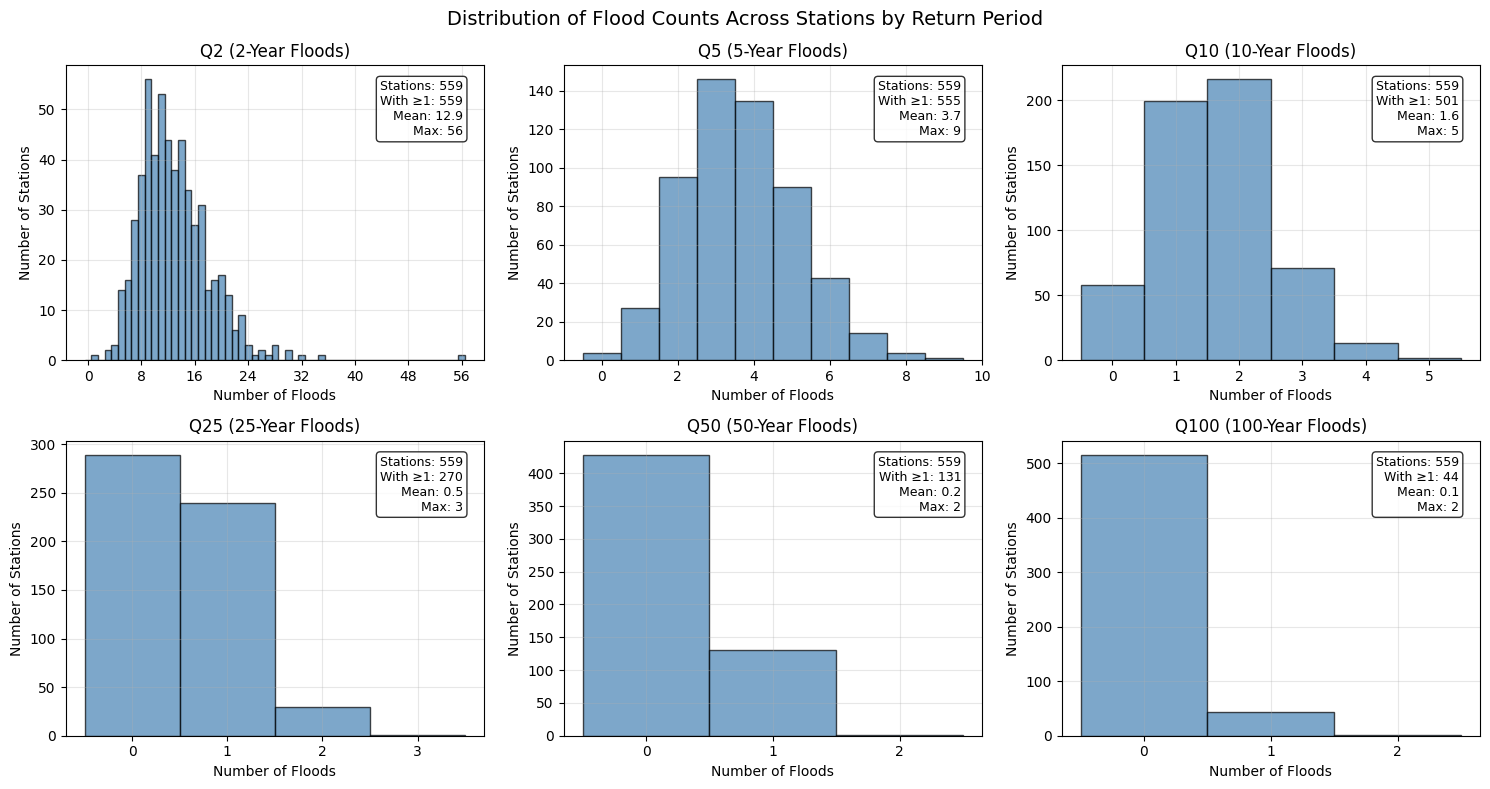

In [42]:
# Plot the histograms of flood counts for each quantile tier
plot_flood_count_histograms(lp3_results)

In [43]:
def plot_flood_severity_histogram(lp3_results: pl.DataFrame):
    """
    Create a histogram showing the distribution of flood_severity_score across sites.
    """
    scores = lp3_results["flood_severity_score"].drop_nulls().to_numpy()

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(scores, bins=30, edgecolor="black", color="steelblue", alpha=0.7)

    ax.set_xlabel("Flood Severity Score")
    ax.set_ylabel("Number of Stations")
    ax.set_title("Distribution of Flood Severity Scores Across Stations")
    ax.grid(True, alpha=0.3)

    stats_text = (
        f"Stations: {len(scores)}\n"
        f"Mean: {scores.mean():.2f}\n"
        f"Median: {np.median(scores):.2f}\n"
        f"Max: {scores.max():.2f}"
    )
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
            verticalalignment="top", horizontalalignment="right",
            fontsize=9, bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

    plt.tight_layout()
    plt.show()

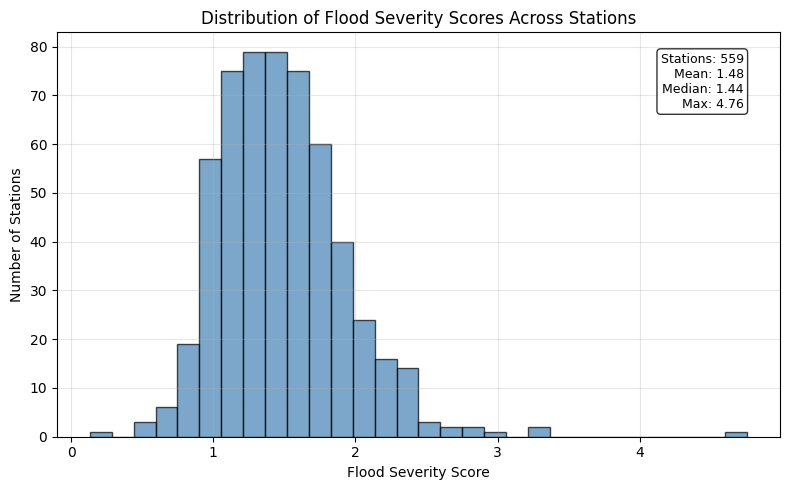

In [44]:
# Plot the histograms of flood severity by gauge location
plot_flood_severity_histogram(lp3_results)

In [45]:
import plotly.express as px
import numpy as np

def plot_gauge_locations(df, title_text, color_variable, colorscale_text, color_min=None, color_max=None, log_scale=False):
    # Filter data based on color variable limits
    filtered_df = df
    
    if color_min is not None:
        filtered_df = filtered_df.filter(pl.col(color_variable) >= color_min)
    
    if color_max is not None:
        filtered_df = filtered_df.filter(pl.col(color_variable) <= color_max)
    
    # Print number of sites
    n_original = df.shape[0]
    n_filtered = filtered_df.shape[0]
    n_removed = n_original - n_filtered
    
    print(f"Sites: {n_filtered:,} of {n_original:,} ({n_removed:,} removed)")
    
    # Convert to pandas for plotly
    plot_df = filtered_df.to_pandas()
    
    # Create log-transformed column if needed
    if log_scale:
        log_col = f"{color_variable}_log"
        plot_df[log_col] = np.log10(plot_df[color_variable])
        color_col = log_col
    else:
        color_col = color_variable
    
    fig = px.scatter_map(
        plot_df,
        lat="latitude",
        lon="longitude",
        color=color_col,
        color_continuous_scale="Viridis",
        # scope="usa",
        hover_name="site_id",
        hover_data={"elevation_m": True},
        title=title_text,
    )
    
    # Update colorbar labels for log scale
    if log_scale:
        # Get tick values in log space
        min_val = plot_df[color_variable].min()
        max_val = plot_df[color_variable].max()
        log_min = np.floor(np.log10(min_val))
        log_max = np.ceil(np.log10(max_val))
        tick_vals = np.arange(log_min, log_max + 1)
        tick_text = [f"{10**v:,.0f}" for v in tick_vals]
        
        fig.update_coloraxes(
            colorbar_title=colorscale_text,
            colorbar_tickvals=tick_vals,
            colorbar_ticktext=tick_text
        )
    else:
        int_min = int(np.floor(plot_df[color_col].min()))
        int_max = int(np.ceil(plot_df[color_col].max()))

        if int_max < 3:
            # Let Plotly handle ticks automatically with decimal intervals
            fig.update_coloraxes(colorbar_title=colorscale_text)
        else:
            step = max(1, (int_max - int_min) // 10)
            tick_vals = list(range(int_min, int_max + 1, step))
            fig.update_coloraxes(
                colorbar_title=colorscale_text,
                colorbar_tickvals=tick_vals,
                colorbar_ticktext=[str(v) for v in tick_vals]
            )

    fig.update_layout(geo=dict(
        showland=True,
        showlakes=True,
        showsubunits=True,
        subunitcolor="gray"
    ))

    center_lat = plot_df["latitude"].mean()
    center_lon = plot_df["longitude"].mean()

    fig.update_layout(
        title_x=0.5,
        margin={"r": 0, "t": 30, "l": 20, "b": 0},
        mapbox_style="carto-positron",
        width=1000,
        height=500,
        map=dict(
            center=dict(lat=center_lat, lon=center_lon),
            zoom=4.0
        )
    )


    fig.show()

In [46]:
# Plot the count of 2 year floods by gauge location
plot_gauge_locations(lp3_results, "Count of 2 Year Floods by Gauge Location", "floods_Q2", "Flood Count (Q2)", 8, None,False)

Sites: 495 of 559 (64 removed)


In [47]:
# Plot the count of 5 year floods by gauge location
plot_gauge_locations(lp3_results, "Count of 5 Year Floods by Gauge Location", "floods_Q5", "Flood Count (Q5)", 5, None, False)

Sites: 152 of 559 (407 removed)


In [48]:
# Plot the count of 10 year floods by gauge location
plot_gauge_locations(lp3_results, "Count of 10 Year Floods by Gauge Location", "floods_Q10", "Flood Count (Q10)", 0, None, False)

Sites: 559 of 559 (0 removed)


In [49]:
# Plot the count of 25 year floods by gauge location
plot_gauge_locations(lp3_results, "Count of 25 Year Floods by Gauge Location", "floods_Q25", "Flood Count (Q25)", 1, None, False)

Sites: 270 of 559 (289 removed)


In [50]:
# Plot the count of 50 year floods by gauge location
plot_gauge_locations(lp3_results, "Count of 50 Year Floods by Gauge Location", "floods_Q50", "Flood Count (Q50)", 1, None, False)

Sites: 131 of 559 (428 removed)


In [51]:
# Plot the count of 10 year flood thresholds by gauge location
plot_gauge_locations(lp3_results, "10 Year Flood Thresholds by Gauge Location", "Q10_cfs", "Q10 (cfs)", 0, None, True)

Sites: 559 of 559 (0 removed)


In [52]:
# Plot the Flood Severity Score by gauge location
plot_gauge_locations(lp3_results, "Flood Severity Score by Gauge Location", "flood_severity_score", "Score", 0, None, False)

Sites: 559 of 559 (0 removed)


In [53]:
from matplotlib.ticker import ScalarFormatter, FuncFormatter, LogLocator

def plot_flood_frequency_curve(
    annual_peaks_df: pl.DataFrame,
    lp3_results: pl.DataFrame,
    site_id: str,
    station_col: str = "site_id",
    discharge_col: str = "peak_discharge_cfs"
):
    """
    Plot annual peak discharge vs annual exceedance probability for a specific site.
    Highlights PILF observations and threshold.
    """
    from matplotlib.ticker import FixedLocator, FuncFormatter
    
    # Get LP3 parameters for this site
    site_params = lp3_results.filter(pl.col(station_col) == site_id)
    
    if site_params.shape[0] == 0:
        print(f"Site {site_id} not found in lp3_results")
        return
    
    # Extract parameters
    mean_log = site_params["mean_log"].to_list()[0]
    std_log = site_params["std_log"].to_list()[0]
    weighted_skew = site_params["weighted_skew"].to_list()[0]
    n_years = site_params["n_years"].to_list()[0]
    state = site_params["state"].to_list()[0]
    
    # Get PILF threshold if available
    pilf_threshold = None
    n_pilfs = 0
    if "pilf_threshold_cfs" in site_params.columns:
        pilf_threshold = site_params["pilf_threshold_cfs"].to_list()[0]
        n_pilfs = site_params["n_pilfs"].to_list()[0]
    
    # Get observed peaks for this site
    site_peaks = (
        annual_peaks_df
        .filter(pl.col(station_col) == site_id)
        .filter(pl.col(discharge_col).is_not_null())
        .filter(pl.col(discharge_col) > 0)
        .select(discharge_col)
        .to_numpy()
        .flatten()
    )
    
    # Sort peaks in descending order for plotting positions
    sorted_peaks = np.sort(site_peaks)[::-1]
    n = len(sorted_peaks)
    
    # Weibull plotting positions (AEP in %)
    ranks = np.arange(1, n + 1)
    aep_observed = (ranks / (n + 1)) * 100
    
    # Separate PILF and non-PILF points
    if pilf_threshold is not None and not np.isnan(pilf_threshold):
        is_pilf = sorted_peaks < pilf_threshold
        pilf_peaks = sorted_peaks[is_pilf]
        pilf_aep = aep_observed[is_pilf]
        non_pilf_peaks = sorted_peaks[~is_pilf]
        non_pilf_aep = aep_observed[~is_pilf]
    else:
        non_pilf_peaks = sorted_peaks
        non_pilf_aep = aep_observed
        pilf_peaks = np.array([])
        pilf_aep = np.array([])
    
    # Generate LP3 frequency curve
    aep_curve = np.array([0.1, 0.2, 0.5, 1, 2, 4, 10, 20, 50, 80, 90, 95, 99])
    exceedance_probs = aep_curve / 100
    non_exceedance_probs = 1 - exceedance_probs
    
    log_Q_curve = pearson3.ppf(non_exceedance_probs, weighted_skew, loc=mean_log, scale=std_log)
    Q_curve = 10 ** log_Q_curve
    
    # Create plot
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Plot non-PILF observed data points
    ax.scatter(
        non_pilf_aep,
        non_pilf_peaks,
        color="steelblue",
        s=50,
        edgecolor="black",
        linewidth=0.5,
        label="Observed Annual Peaks",
        zorder=3
    )
    
    # Plot PILF points (highlighted)
    if len(pilf_peaks) > 0:
        ax.scatter(
            pilf_aep,
            pilf_peaks,
            color="orange",
            s=70,
            edgecolor="red",
            linewidth=1.5,
            marker="v",
            label=f"PILF Observations (n={len(pilf_peaks)})",
            zorder=4
        )
    
    # Plot LP3 frequency curve
    ax.plot(
        aep_curve,
        Q_curve,
        color="darkred",
        linewidth=2,
        label="LP3 Frequency Curve",
        zorder=2
    )
        
    # Set log scale for y-axis
    ax.set_yscale("log")

    # Force standard number format (no scientific notation)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    
    # Set x-axis to probability scale (reversed)
    ax.set_xscale("log")
    ax.invert_xaxis()
    
    # Format x-axis as percentages
    tick_positions = [0.2, 0.5, 1, 2, 5, 10, 20, 50, 100]
    ax.xaxis.set_major_locator(FixedLocator(tick_positions))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:g}%"))
    
    # Labels and title
    ax.set_xlabel("Annual Exceedance Probability (%)", fontsize=12)
    ax.set_ylabel("Peak Discharge (cfs)", fontsize=12)
    ax.set_title(f"Flood Frequency Curve - Site {site_id}", fontsize=14)
    
    # Statistics box
    stats_text = (
        f"N = {n_years} years\n"
        f"Weighted Skew = {weighted_skew:.3f}\n"
        f"Mean (log) = {mean_log:.3f}\n"
        f"Std Dev (log) = {std_log:.3f}\n"
        f"State = {state}"
    )
    if pilf_threshold is not None and not np.isnan(pilf_threshold):
        stats_text += f"\nPILFs = {n_pilfs}"
    
    ax.text(
        0.02, 0.98, stats_text,
        transform=ax.transAxes,
        verticalalignment="top",
        horizontalalignment="left",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray")
    )
    
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3, which="both")
    
    plt.tight_layout()
    # plt.show()
    return fig

In [54]:
from matplotlib.dates import YearLocator, DateFormatter

def plot_daily_streamflow_with_thresholds(
    sfd_df: pl.DataFrame,
    lp3_results: pl.DataFrame,
    site_id: str,
    station_col: str = "site_id",
    date_col: str = "observed_date",
    streamflow_col: str = "streamflow_cfs_max",
    # gage_height_col: str = "gage_height_ft_max",
    return_periods: list = [2, 5, 10, 25, 50, 100]
):
    """
    Plot daily streamflow and gage height with LP3 flood quantile thresholds.
    """
    from matplotlib.ticker import FuncFormatter
    
    # Filter data for this site
    site_data = (
        sfd_df
        .filter(pl.col(station_col) == site_id)
        .sort(date_col)
    )
    
    if site_data.shape[0] == 0:
        print(f"Site {site_id} not found in sfd_df")
        return
    
    # Get LP3 results for this site
    site_params = lp3_results.filter(pl.col(station_col) == site_id)
    
    if site_params.shape[0] == 0:
        print(f"Site {site_id} not found in lp3_results")
        return
    
    # Extract quantile thresholds
    thresholds = {}
    for T in return_periods:
        col_name = f"Q{T}_cfs"
        if col_name in site_params.columns:
            thresholds[T] = site_params[col_name].to_list()[0]
    
    # Extract data for plotting
    dates = site_data[date_col].to_numpy()
    streamflow = site_data[streamflow_col].to_numpy()
    # gage_height = site_data[gage_height_col].to_numpy()
    
    # Create figure with dual y-axes
    fig, ax1 = plt.subplots(figsize=(14, 7))
    # ax2 = ax1.twinx()
    
    # Plot streamflow on primary axis
    ax1.plot(
        dates,
        streamflow,
        color="steelblue",
        linewidth=0.5,
        alpha=0.8,
        label="Daily Streamflow"
    )
    
    # # Plot gage height on secondary axis
    # ax2.plot(
    #     dates,
    #     gage_height,
    #     color="darkgreen",
    #     linewidth=0.5,
    #     alpha=0.6,
    #     label="Gage Height"
    # )
    
    # Add quantile threshold lines with labels
    colors = {5: "gold", 10: "orange", 25: "red", 50: "darkred"}
    
    for T, Q in thresholds.items():
        color = colors.get(T, "gray")
        ax1.axhline(
            y=Q,
            color=color,
            linestyle="--",
            linewidth=1.5,
            zorder=5
        )
    
        # Label inside plot, near left edge
        ax1.text(
            0.02,  # 2% from left edge
            Q,
            f"Q{T}: {Q:,.0f} cfs",
            color=color,
            fontsize=9,
            va="bottom",
            ha="left",
            fontweight="bold",
            transform=ax1.get_yaxis_transform(),  # x in axes coords, y in data coords
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8, edgecolor=color)
        )

    
    
    # Format primary y-axis (streamflow) with commas
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
    
    # Labels and formatting
    ax1.set_xlabel("Date", fontsize=12)
    ax1.set_ylabel("Streamflow (cfs)", fontsize=12, color="steelblue")
    # ax2.set_ylabel("Gage Height (ft)", fontsize=12, color="darkgreen")
    
    ax1.tick_params(axis="y", labelcolor="steelblue")
    # ax2.tick_params(axis="y", labelcolor="darkgreen")
    
    ax1.set_title(f"Daily Streamflow and Quantile Thresholds - Site {site_id}", fontsize=14)
    
    # Grid
    ax1.grid(True, alpha=0.3, which="both")
    ax1.xaxis.set_major_locator(YearLocator(1))
    ax1.xaxis.set_major_formatter(DateFormatter("%Y"))
    # plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha="right")
    
    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    # ls2, labels2 = ax2.get_legend_handles_labels()
    # ineax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10)
    ax1.legend(lines1, labels1, loc="upper right", fontsize=10)
    
    plt.tight_layout()
    # plt.show()
    return fig


Investigating individual Gauge Sites

shape: (17, 4)
┌──────────┬──────┬────────────────────┬────────────┐
│ site_id  ┆ year ┆ peak_discharge_cfs ┆ peak_date  │
│ ---      ┆ ---  ┆ ---                ┆ ---        │
│ str      ┆ i32  ┆ f64                ┆ date       │
╞══════════╪══════╪════════════════════╪════════════╡
│ 06911000 ┆ 2008 ┆ 1500.0             ┆ 2008-09-22 │
│ 06911000 ┆ 2009 ┆ 2140.0             ┆ 2009-05-05 │
│ 06911000 ┆ 2010 ┆ 2250.0             ┆ 2010-06-28 │
│ 06911000 ┆ 2011 ┆ 604.0              ┆ 2011-02-27 │
│ 06911000 ┆ 2012 ┆ 144.0              ┆ 2012-05-01 │
│ 06911000 ┆ 2013 ┆ 63.2               ┆ 2013-08-12 │
│ 06911000 ┆ 2014 ┆ 551.0              ┆ 2014-06-22 │
│ 06911000 ┆ 2015 ┆ 2040.0             ┆ 2015-06-01 │
│ 06911000 ┆ 2016 ┆ 2510.0             ┆ 2016-06-02 │
│ 06911000 ┆ 2017 ┆ 1370.0             ┆ 2017-04-18 │
│ 06911000 ┆ 2018 ┆ 49.0               ┆ 2018-08-30 │
│ 06911000 ┆ 2019 ┆ 3490.0             ┆ 2019-06-12 │
│ 06911000 ┆ 2020 ┆ 1490.0             ┆ 2020-05-22 │
│ 06911000 ┆ 

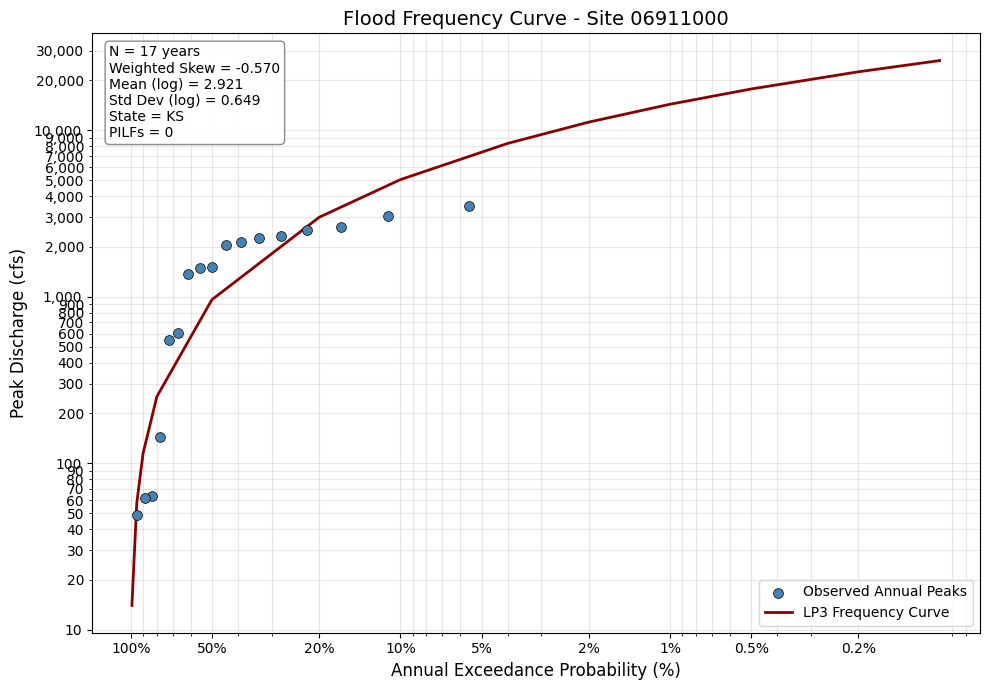

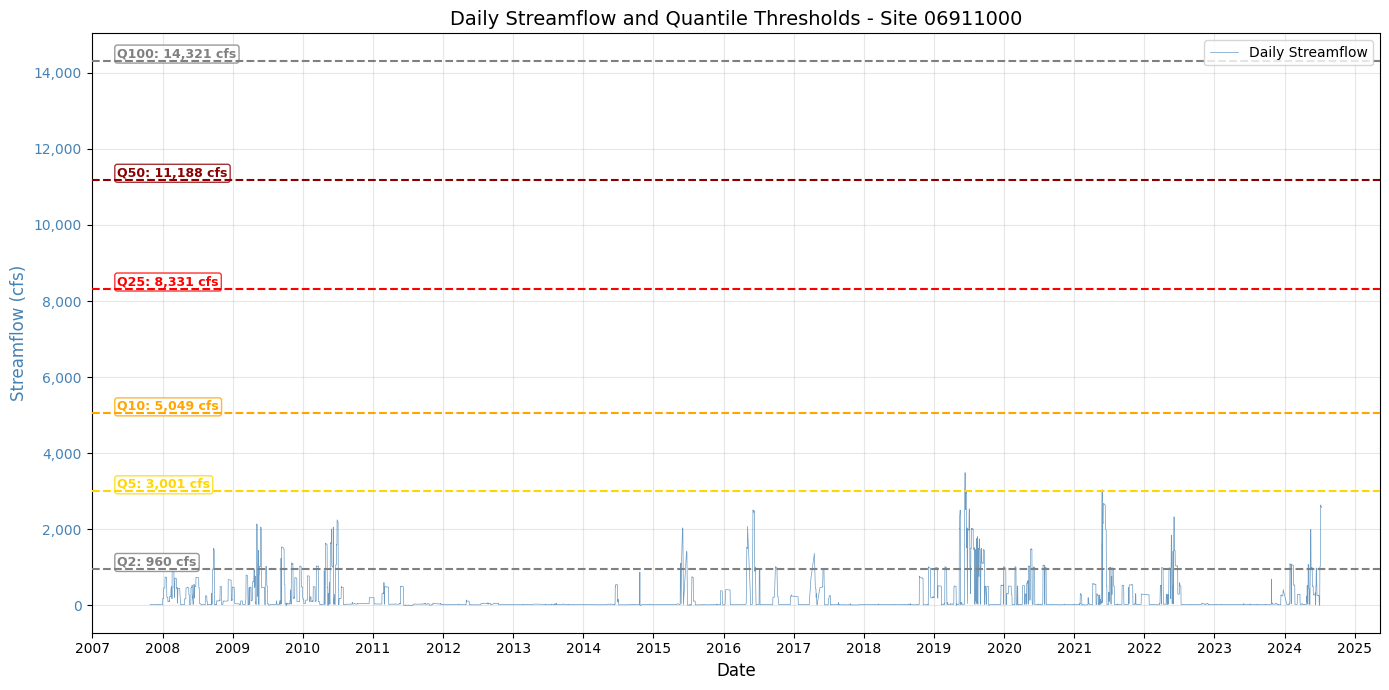

In [56]:
inv_gauge_site_id = "06911000"
print(annual_peaks_sfd.filter(pl.col("site_id") == inv_gauge_site_id))
plot_flood_frequency_curve(annual_peaks_sfd, lp3_results, inv_gauge_site_id)
plot_daily_streamflow_with_thresholds(sfd_df, lp3_results, inv_gauge_site_id);

In [57]:
with pl.Config(tbl_cols=-1):
    print(lp3_results.filter(pl.col("site_id") == inv_gauge_site_id))

shape: (1, 30)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ sit ┆ sta ┆ n_y ┆ mea ┆ std ┆ sta ┆ sta ┆ reg ┆ reg ┆ wei ┆ pil ┆ pil ┆ n_p ┆ n_r ┆ Q2_ ┆ Q5_ ┆ Q10 ┆ Q25 ┆ Q50 ┆ Q10 ┆ lat ┆ lon ┆ ele ┆ flo ┆ flo ┆ flo ┆ flo ┆ flo ┆ flo ┆ flo │
│ e_i ┆ te  ┆ ear ┆ n_l ┆ _lo ┆ tio ┆ tio ┆ ion ┆ ion ┆ ght ┆ f_t ┆ f_t ┆ ilf ┆ eta ┆ cfs ┆ cfs ┆ _cf ┆ _cf ┆ _cf ┆ 0_c ┆ itu ┆ git ┆ vat ┆ ods ┆ ods ┆ ods ┆ ods ┆ ods ┆ ods ┆ od_ │
│ d   ┆ --- ┆ s   ┆ og  ┆ g   ┆ n_s ┆ n_m ┆ al_ ┆ al_ ┆ ed_ ┆ hre ┆ hre ┆ s   ┆ ine ┆ --- ┆ --- ┆ s   ┆ s   ┆ s   ┆ fs  ┆ de  ┆ ude ┆ ion ┆ _Q2 ┆ _Q5 ┆ _Q1 ┆ _Q2 ┆ _Q5 ┆ _Q1 ┆ sev │
│ --- ┆ str ┆ --- ┆ --- ┆ --- ┆ kew ┆ se  ┆ ske ┆ mse ┆ ske ┆ sho ┆ sho ┆ --- ┆ d   ┆ f64 ┆ f64 ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ --- ┆ _m  ┆ --- ┆ --- ┆ 0   ┆ 5   ┆ 0   ┆ 00  ┆ eri │
│ str ┆     ┆ i64 ┆ f64 ┆ f64 ┆ --- ┆ --- ┆ w   ┆ --- ┆ w   ┆ ld_ ┆ ld_ ┆ i

Create PowerPoint with Graphs of Top Sites Containing Severe Floods

In [ ]:
import io
import subprocess
import json
import tempfile
import matplotlib
matplotlib.use("Agg")  # non-interactive backend for saving to files
import matplotlib.pyplot as plt


def create_lp3_results_ppt(
    lp3_results: pl.DataFrame,
    sfd_df: pl.DataFrame,
    annual_peaks_df: pl.DataFrame,
    top_n: int = 10,
    output_path: str = r"C:\Users\mroth\OneDrive\Documents\Rice\COMP 549 DSCI 535 901 Capstone\Project",
    filename: str = "LP3_Results.pptx",
    station_col: str = "site_id",
    return_periods: list = [2, 5, 10, 25, 50, 100],
):
    """
    Creates a PowerPoint presentation with one slide per site for the top N
    sites ranked by flood_severity_score.

    Each slide contains:
    - Title: "{site_id}: {flood_severity_score:.2f}"
    - Left:  plot_flood_frequency_curve  (h=3.8", vertically centered)
    - Right: plot_daily_streamflow_with_thresholds (h=3.8", vertically centered)
    """

    # Select top N sites
    top_sites = (
        lp3_results
        .sort("flood_severity_score", descending=True)
        .head(top_n)
    )

    # Build temp directory for PNGs and the JS script
    tmp_dir = tempfile.mkdtemp(prefix="lp3_ppt_")
    slides_data = []   # list of dicts consumed by JS

    for row in top_sites.iter_rows(named=True):
        site_id = row[station_col]
        score   = row["flood_severity_score"]

        # ---- flood frequency curve ----
        fc_path = os.path.join(tmp_dir, f"{site_id}_freq_curve.png")
        try:
            fig = plot_flood_frequency_curve(
                lp3_results=lp3_results,
                annual_peaks_df=annual_peaks_df,
                site_id=site_id,
                station_col=station_col,
            )
            fig.savefig(fc_path, dpi=150, bbox_inches="tight")
            plt.close(fig)
        except Exception as e:
            print(f"  [WARN] freq curve for {site_id}: {e}")
            fc_path = None

        # ---- daily streamflow ----
        sf_path = os.path.join(tmp_dir, f"{site_id}_streamflow.png")
        try:
            fig = plot_daily_streamflow_with_thresholds(
                sfd_df=sfd_df,
                lp3_results=lp3_results,
                site_id=site_id,
                station_col=station_col,
                return_periods=return_periods,
            )
            fig.savefig(sf_path, dpi=150, bbox_inches="tight")
            plt.close(fig)
        except Exception as e:
            print(f"  [WARN] streamflow for {site_id}: {e}")
            sf_path = None

        slides_data.append({
            "title":   f"{site_id}: {score:.2f}",
            "leftImg":  fc_path,
            "rightImg": sf_path,
        })
        print(f"  Rendered {site_id}  (score={score:.2f})")


    # Write pptxgenjs Node script

    full_output = os.path.join(output_path, filename)
    js_path     = os.path.join(tmp_dir, "build_ppt.js")

    # Slide geometry (LAYOUT_WIDE = 13.33" × 7.5")
    SLIDE_W      = 13.33
    SLIDE_H      = 7.5
    TITLE_H      = 0.6
    TITLE_Y      = 0.15
    CONTENT_TOP  = TITLE_Y + TITLE_H + 0.05
    CONTENT_H    = SLIDE_H - CONTENT_TOP
    IMG_H        = 3.8
    IMG_Y        = CONTENT_TOP + (CONTENT_H - IMG_H) / 2
    IMG_W        = 6.3      # wider images to fill the larger canvas
    LEFT_X       = 0.2
    RIGHT_X      = SLIDE_W - IMG_W - 0.2

    js_slides = json.dumps(slides_data, ensure_ascii=False)

    js_script = f"""
const pptxgen = require("pptxgenjs");

const slides = {js_slides};
const OUTPUT = {json.dumps(full_output)};

const TITLE_Y  = {TITLE_Y};
const TITLE_H  = {TITLE_H};
const IMG_Y    = {round(IMG_Y, 4)};
const IMG_H    = {IMG_H};
const IMG_W    = {IMG_W};
const LEFT_X   = {LEFT_X};
const RIGHT_X  = {round(RIGHT_X, 4)};
const SLIDE_W  = {SLIDE_W};

let pres = new pptxgen();
pres.layout = "LAYOUT_WIDE";
pres.title  = "LP3 Flood Severity Results";

for (const s of slides) {{
  let slide = pres.addSlide();
  slide.background = {{ color: "FFFFFF" }};

  // Title
  slide.addText(s.title, {{
    x: 0.3,
    y: TITLE_Y,
    w: SLIDE_W - 0.6,
    h: TITLE_H,
    fontSize: 20,
    bold: true,
    color: "1F3864",
    fontFace: "Calibri",
    align: "center",
    valign: "middle",
    margin: 0,
  }});

  // Thin separator line under title
  slide.addShape(pres.shapes.LINE, {{
    x: 0.3,
    y: TITLE_Y + TITLE_H,
    w: SLIDE_W - 0.6,
    h: 0,
    line: {{ color: "1F3864", width: 1 }},
  }});

  // Left image: flood frequency curve
  if (s.leftImg) {{
    slide.addImage({{
      path: s.leftImg,
      x: LEFT_X,
      y: IMG_Y,
      w: IMG_W,
      h: IMG_H,
      sizing: {{ type: "contain", w: IMG_W, h: IMG_H }},
    }});
  }}

  // Right image: daily streamflow
  if (s.rightImg) {{
    slide.addImage({{
      path: s.rightImg,
      x: RIGHT_X,
      y: IMG_Y,
      w: IMG_W,
      h: IMG_H,
      sizing: {{ type: "contain", w: IMG_W, h: IMG_H }},
    }});
  }}
}}

pres.writeFile({{ fileName: OUTPUT }})
  .then(() => console.log("Saved: " + OUTPUT))
  .catch(err => {{ console.error(err); process.exit(1); }});
"""

    with open(js_path, "w", encoding="utf-8") as f:
        f.write(js_script)

    # Run Node.js to build the file
    print(f"\nInstalling pptxgenjs in temp directory...")
    subprocess.run(
        "npm install pptxgenjs",
        cwd=tmp_dir,
        capture_output=True,
        shell=True
    )

    print(f"\nBuilding PowerPoint → {full_output}")
    result = subprocess.run(
        "node build_ppt.js",
        capture_output=True, text=True,
        cwd=tmp_dir,
        shell=True
    )
    if result.returncode != 0:
        print("Node.js STDERR:", result.stderr)
        raise RuntimeError(f"pptxgenjs failed: {result.stderr}")

    print(result.stdout.strip())
    print("Done.")

In [ ]:
# Creates the PowerPoint 
output_path = r"C:\Users\mroth\OneDrive\Documents\Rice\COMP 549 DSCI 535 901 Capstone\Project"

# create_lp3_results_ppt(
#     lp3_results=lp3_results,
#     sfd_df=sfd_df,
#     annual_peaks_df=annual_peaks_sfd,
#     top_n=37,
#     output_path=output_path,  
# )

In [58]:
def plot_gauge_locations_filtered(df, threshold=2.18, title_text="Gauge Site Status by Flood Severity Score"):
    # Split into kept and discarded
    plot_df = df.to_pandas()
    plot_df["status"] = plot_df["flood_severity_score"].apply(
        lambda x: "Kept" if x >= threshold else "Discarded"
    )

    # Define colors explicitly
    color_map = {
        "Kept": "steelblue",
        "Discarded": "tomato"
    }

    # Print summary
    n_kept = (plot_df["status"] == "Kept").sum()
    n_discarded = (plot_df["status"] == "Discarded").sum()
    print(f"Kept: {n_kept:,} | Discarded: {n_discarded:,} | Total: {len(plot_df):,}")

    fig = px.scatter_map(
        plot_df,
        lat="latitude",
        lon="longitude",
        color="status",
        color_discrete_map=color_map,
        hover_name="site_id",
        hover_data={"elevation_m": True, "flood_severity_score": True},
        title=title_text,
        category_orders={"status": ["Kept", "Discarded"]}  # controls legend order
    )

    center_lat = plot_df["latitude"].mean()
    center_lon = plot_df["longitude"].mean()

    fig.update_layout(
        title_x=0.5,
        margin={"r": 0, "t": 30, "l": 20, "b": 0},
        mapbox_style="carto-positron",
        width=1000,
        height=500,
        map=dict(
            center=dict(lat=center_lat, lon=center_lon),
            zoom=4.0
        ),
        legend=dict(
            title="Site Status",
            orientation="v",
            x=0.01,
            y=0.99,
            bgcolor="rgba(255,255,255,0.7)",
            bordercolor="gray",
            borderwidth=1
        )
    )

    fig.show()




In [59]:
# Plot all of the gauge sites, but differentiate based on a threshold value of flood severity score.
plot_gauge_locations_filtered(lp3_results, threshold=2.18)

Kept: 37 | Discarded: 522 | Total: 559


Create a JSON file to be easily read by other notebooks and models that stores the top 37 gauge sites and their respective quantile thresholds.

In [62]:
import json

q_columns = ["Q2_cfs", "Q5_cfs", "Q10_cfs", "Q25_cfs", "Q50_cfs", "Q100_cfs"]

# Filter to top 37 sites with flood_severity_score >= 2.18
top_sites = (
    lp3_results
    .filter(pl.col("flood_severity_score") >= 2.18)
    .sort("flood_severity_score", descending=True)
    .head(37)
)

# Build nested dictionary
site_thresholds = {}
for row in top_sites.iter_rows(named=True):
    site_id = row["site_id"]
    site_thresholds[site_id] = {q: row[q] for q in q_columns if row[q] is not None}

# Write to JSON
output_path = "../../src/static/top_site_quantile_thresholds.json"
with open(output_path, "w") as f:
    json.dump(site_thresholds, f, indent=4)

print(f"Wrote {len(site_thresholds)} sites to {output_path}")
print(list(site_thresholds.keys()))

Wrote 37 sites to ../../src/static/top_site_quantile_thresholds.json
['06911000', '06401500', '06870300', '06915000', '06911490', '06864000', '06869500', '06342260', '06440200', '06784000', '06912500', '06821500', '06359500', '06447450', '06882510', '06865500', '06343000', '06867000', '06332515', '06477500', '06868200', '06452320', '06913000', '06471800', '06463500', '06799100', '06913500', '06408650', '06400000', '06402500', '06810000', '06131200', '06894200', '06344600', '06347000', '06821190', '06793000']


In [ ]:
del sfd_df, artifact, artifact_dir
gc.collect()